# Model

In this notebook, I will test some models to determine which model performs best.  I want my final model to be interpretable so I will only be testing white box models.

## Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
random_state = 42

sys.path.append(os.path.abspath(".."))

import python_code.Scripts3 as sc
import python_code.Reference as ref
import pickle

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score
from treeinterpreter import treeinterpreter as ti
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

print("Everything imported successfully")

Everything imported successfully


In [2]:
df = pd.read_csv("../data/final.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 33 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CERTHHSZ  3904 non-null   float64
 1   FSGA      3904 non-null   float64
 2   LIQRESOR  3904 non-null   float64
 3   FSUNEARN  3904 non-null   float64
 4   FSERNDED  3904 non-null   float64
 5   FSASSET   3904 non-null   float64
 6   FSTOTDED  3904 non-null   float64
 7   FSSLTDE2  3904 non-null   float64
 8   TPOV      3904 non-null   float64
 9   FSEARN    3904 non-null   float64
 10  FSGRINC   3904 non-null   float64
 11  FSDIS     3904 non-null   float64
 12  FSNELDER  3904 non-null   float64
 13  FSSLTDED  3904 non-null   float64
 14  FSNONCIT  3904 non-null   float64
 15  FSSSI     3904 non-null   float64
 16  HWGT      3904 non-null   float64
 17  RAWNET    3904 non-null   float64
 18  FSTANF    3904 non-null   float64
 19  FSERNDE2  3904 non-null   float64
 20  FSNETINC  3904 non-null   float64
 21  FS

## Data Prep
_CAPITAL X, lowercase y_

In [4]:
X = df.drop(columns = ['CAT_ELIG'])
y = df['CAT_ELIG']

In [5]:
#baseline, NULL Model
y.value_counts(normalize=True)

CAT_ELIG
1.0    0.662398
0.0    0.337602
Name: proportion, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=random_state)

In [7]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [8]:
np.savetxt('../data/TrainTest/X_train.csv',X_train,delimiter=',')
np.savetxt('../data/TrainTest/y_train.csv',y_train,delimiter=',')
np.savetxt('../data/TrainTest/X_test.csv',X_test,delimiter=',')
np.savetxt('../data/TrainTest/y_test.csv',y_test,delimiter=',')

In [9]:
pca = PCA(n_components=10,random_state=42)
pca.fit(X_train)
X_train_pc = pca.transform(X_train)
X_test_pc = pca.transform(X_test)

## Models

### _Overview model selection_

**White box models**
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient
- Ada
- SVM
- Naive Bayes

In [10]:
models = {
    'LogReg': LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boost':GradientBoostingClassifier(),
    'Ada Boost':AdaBoostClassifier(),
    'SVC':SVC(),
    'Naive Bayes':GaussianNB()}

In [11]:
#adapted from Dan Brown lecture
final = pd.DataFrame(columns = ['cross_val_train','cross_val_test','test_recall','test_precision'])
idx=0
while idx < len(models.keys()):
    for name,model in models.items():
        results = {}
        results['name']=name
        name=model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        results['cross_val_train'] = np.mean(cross_val_score(model,X_train,y_train,cv=4))
        results['cross_val_test'] = np.mean(cross_val_score(model,X_test,y_test,cv=4))
        results['test_recall'] = recall_score(y_test, y_pred_test)
        results['test_precision'] = precision_score(y_test, y_pred_test)
        final = pd.concat([final, pd.DataFrame([results])], ignore_index=True)
        idx+=1

In [12]:
final.set_index('name')

,cross_val_train,cross_val_test,test_recall,test_precision
name,,,,
LogReg,0.884334,0.862628,0.900262,0.903821
Decision Tree,0.904466,0.917235,0.933071,0.937995
Random Forest,0.941069,0.935154,0.965879,0.958333
Gradient Boost,0.941801,0.933447,0.950131,0.960212
Ada Boost,0.878843,0.882253,0.910761,0.906005
SVC,0.8847,0.854949,0.901575,0.928378
Naive Bayes,0.767204,0.741468,0.833333,0.908441


Adding PCA to the data and comparing the scores:

In [13]:
pc_final = pd.DataFrame(columns = ['cross_val_train','cross_val_test','test_recall','test_precision'])
idx=0
while idx < len(models.keys()):
    for name,model in models.items():
        results = {}
        results['name']=name
        name=model.fit(X_train_pc, y_train)
        y_pred_train = model.predict(X_train_pc)
        y_pred_test = model.predict(X_test_pc)
        results['cross_val_train'] = np.mean(cross_val_score(model,X_train_pc,y_train,cv=4))
        results['cross_val_test'] = np.mean(cross_val_score(model,X_test_pc,y_test,cv=4))
        results['test_recall'] = recall_score(y_test, y_pred_test)
        results['test_precision'] = precision_score(y_test, y_pred_test)
        pc_final = pd.concat([pc_final, pd.DataFrame([results])], ignore_index=True)
        idx+=1

In [14]:
pc_final.set_index('name')

,cross_val_train,cross_val_test,test_recall,test_precision
name,,,,
LogReg,0.783675,0.763652,0.892388,0.770102
Decision Tree,0.835286,0.811433,0.895013,0.864385
Random Forest,0.886896,0.861775,0.939633,0.899497
Gradient Boost,0.877379,0.860068,0.908136,0.882653
Ada Boost,0.838214,0.822526,0.885827,0.858779
SVC,0.831991,0.834471,0.874016,0.871728
Naive Bayes,0.72694,0.713311,0.958005,0.6926


### Model Selection

The best performing models are Random Forest and Gradient Boost without PCA.  PCA seemed to exaggerate overfitting on all models. The Gradient Boost has the least overfitting.  Therefore, I will GridSearch over a RandomForest with Gradient Boost.  Just to make sure, I will check out the classification report for each model to verify each class is represented fairly well.

In [15]:
for name,model in models.items():
    name = model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred_test))
    print('\n')

LogisticRegression()
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82       410
         1.0       0.90      0.90      0.90       762

    accuracy                           0.87      1172
   macro avg       0.86      0.86      0.86      1172
weighted avg       0.87      0.87      0.87      1172



DecisionTreeClassifier()
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       410
         1.0       0.94      0.94      0.94       762

    accuracy                           0.92      1172
   macro avg       0.91      0.91      0.91      1172
weighted avg       0.92      0.92      0.92      1172



RandomForestClassifier()
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       410
         1.0       0.96      0.96      0.96       762

    accuracy                           0.95      1172
   macro avg       0.95      0.95      0.95      1172

What we see is that Random Forest and Gradient Boosting represent the classes most fairly among all other models.  Since there is an inbalance of classes for the target variable (2007 data had some people who qualified and some who didn't, whereas everyone qualified for SNAP in 2017) I would expect boosting would be essential to this model.

## Running Models

### _Random forest_

I will start with Random Forest for interpretability.

In [16]:
rf = RandomForestClassifier()
params={'max_depth':[None, 3, 4],
       'max_features':[None, 'sqrt'], # Changed 'auto' to 'sqrt'
       'n_estimators':[75, 100, 125]}
rf_gs = GridSearchCV(rf,param_grid=params)
rf_gs.fit(X_train,y_train)
print(rf_gs.best_score_)
rf_gs.best_params_

0.9432616134627103


{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 75}

The result shows the defaults were the best model.

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
instances = X_test[[735]]
instances

array([[ 1.02614408, -0.1335093 , -0.24501332, -0.91848291, -0.59758589,
        -0.24309398,  0.39411313, -0.87253073, -1.49056789, -0.59800159,
        -1.25472977, -0.51403261, -0.40909055,  1.0459183 ,  1.78070948,
        -0.42833737, -0.51614194, -0.88061189, -0.34230342, -0.56404251,
        -0.8826584 , -1.59315573,  1.02614408, -1.28640995, -0.59885312,
         1.00652396, -0.76825854, -0.55893964, -0.03517855, -0.36488324,
        -0.35352552, -0.02833014]])

In [19]:
ft_list = []
prediction, bias, contributions = ti.predict(rf, instances)
print( "Prediction", prediction)
print( "Bias (trainset prior)", bias)
print ("Feature contributions:")
for c, feature in zip(contributions[0], 
                             X.columns):
    ft_list.append((feature, np.round(c, 2)))
    print (feature, c)
    
labels, values = zip(*ft_list)

Prediction [[0.67 0.33]]
Bias (trainset prior) [[0.33264641 0.66735359]]
Feature contributions:
CERTHHSZ [ 0.03142836 -0.03142836]
FSGA [ 0.00406825 -0.00406825]
LIQRESOR [-0.02494631  0.02494631]
FSUNEARN [ 0.02158869 -0.02158869]
FSERNDED [-0.00971817  0.00971817]
FSASSET [-0.02692926  0.02692926]
FSTOTDED [-0.05005697  0.05005697]
FSSLTDE2 [ 0.01015475 -0.01015475]
TPOV [-0.00241052  0.00241052]
FSEARN [-0.01212439  0.01212439]
FSGRINC [-0.00373576  0.00373576]
FSDIS [-0.00099837  0.00099837]
FSNELDER [-0.00063848  0.00063848]
FSSLTDED [ 0.11824047 -0.11824047]
FSNONCIT [ 0.00823046 -0.00823046]
FSSSI [ 0.01377878 -0.01377878]
HWGT [ 0.05426404 -0.05426404]
RAWNET [-0.00050857  0.00050857]
FSTANF [ 0.02921222 -0.02921222]
FSERNDE2 [-0.0076821  0.0076821]
FSNETINC [-0.00647027  0.00647027]
FSSTDDE2 [ 0.05077617 -0.05077617]
FSUSIZE [ 0.03647282 -0.03647282]
FSTOTDE2 [ 0.00884359 -0.00884359]
RAWERND [-0.01068682  0.01068682]
SHELDED [ 0.09445171 -0.09445171]
WRK_POOR [-0.00624497  0.

In [20]:
df1 = pd.DataFrame(ft_list,columns=['feature','array'])
df2 = pd.DataFrame(df1["array"].to_list(), columns=['pred_0', 'pred_1'])
coef_df = pd.concat([df1,df2],axis=1).drop(columns=['array'])
coef_df.to_csv('../data/2018_indicators/coef.csv',index=None)

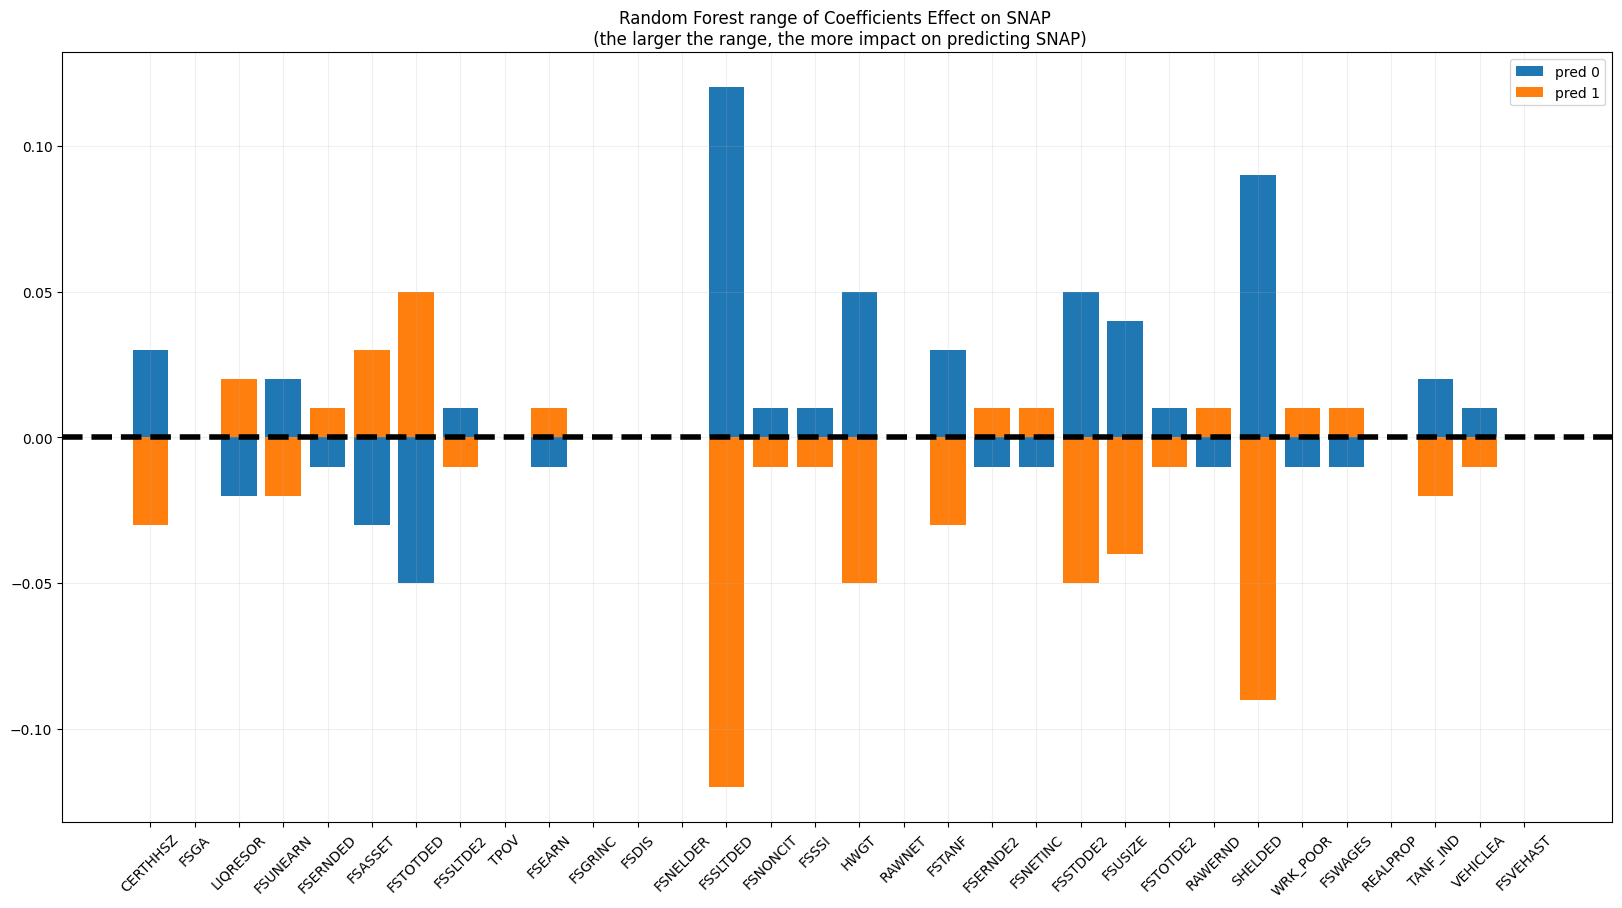

In [21]:
fig, ax = plt.subplots(figsize=(20,10))
plt.title('Random Forest range of Coefficients Effect on SNAP \n (the larger the range, the more impact on predicting SNAP)')
plt.grid(zorder=0,alpha = 0.2)
xs = np.arange(len(labels))
ax.bar(xs,coef_df['pred_0'], label = 'pred 0')
ax.bar(xs,coef_df['pred_1'],label = 'pred 1')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
ax.set_xticks(coef_df.index)
ax.set_xticklabels(coef_df['feature'],rotation = 45)
plt.legend()
plt.savefig('../images/rf_corr.png');

### _Extra Tree Classifier_

I will compare a gridsearch Extra Tree classifier to see if it should be added to the ensemble. 

In [22]:
et = ExtraTreeClassifier()
params={'max_depth':[None,3,4],
       'max_features':[None,'sqrt'],
       'max_leaf_nodes':[5,10]}
et_gs = GridSearchCV(et,param_grid=params)
et_gs.fit(X_train,y_train)
print(et_gs.best_score_)
et_gs.best_params_

0.8455042824329844


{'max_depth': None, 'max_features': None, 'max_leaf_nodes': 10}

It seems the random with replacement that isn't offered in the Extra Tree Classifier is important to predicting SNAP eligibility.  Further magnifying the more than slight class imbalance of the target column.  Therefore, Extra Tree Classifier will not be used in the Ensemble.

### _Bagging Classifier_

Since there is slight overfitting due to less variability in my target class, I will test a bagging classifier to see if I should place it in my Vote Ensemble.

In [23]:
bag = BaggingClassifier()
bag.fit(X_train,y_train)
y_pred_train = bag.predict(X_train)
y_pred_test = bag.predict(X_test)
print(f'cross_val_train = {np.mean(cross_val_score(model,X_train_pc,y_train,cv=4))}')
print(f'cross_val_test = {np.mean(cross_val_score(model,X_test_pc,y_test,cv=4))}')
print(f'test_recall = {recall_score(y_test, y_pred_test)}')
print(f'test_precision = {precision_score(y_test, y_pred_test)}')

cross_val_train = 0.7269399707174231
cross_val_test = 0.7133105802047782
test_recall = 0.952755905511811
test_precision = 0.9440832249674902


The cross val score is actually pretty low for both train and test, but it doesn't appear to be overfitting.  The test recall and precision is actually very high, meaning it is predicting positives very acurately.  I will therefore add it to my vote ensemble.  Because predicting positive (ie. those that are projected to be on SNAP) is more beneficial in targeting groups that are at risk.  

## Final Model

In [25]:
vote = VotingClassifier([
    ('rf',RandomForestClassifier(bootstrap=False,n_estimators=1000)),
    ('gb',GradientBoostingClassifier(max_depth=10,subsample=0.8)),
    ('bag',BaggingClassifier(n_estimators = 10))
])

In [26]:
vote.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('gb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [27]:
filename = '../data/final_model.sav'
pickle.dump(vote, open(filename, 'wb'))